# 常用拟合算法代码示例

拟合是用一条曲线去"贴合"离散数据点的过程，目标是找到能概括数据整体规律的函数形式。

拟合和插值的区别：插值要求曲线**精确经过**每个数据点，拟合只要求曲线**尽可能接近**数据点（允许有误差）。

本 Notebook 按顺序覆盖数学建模竞赛中最常用的 8 种拟合方法，每个方法的注释中都说明了输入、输出、优缺点和适用场景。


## 准备工作

先导入所有需要的库，后面不再重复导入。


In [2]:
# 导入拟合所需的所有库。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示和绘图参数。
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 5)

# 固定随机种子，确保可重复性。
np.random.seed(42)

print("所有库导入成功")


所有库导入成功


# 一、多项式拟合

多项式拟合是最基础的拟合方法，用多项式 $y = a_0 + a_1 x + a_2 x^2 + \cdots + a_n x^n$ 去逼近数据。`numpy.polyfit` 使用最小二乘法求解系数，使用方便但阶数过高容易过拟合。

- **输入**：x 和 y 的数组，以及选定的多项式阶数
- **输出**：多项式系数（从高次到低次排列），以及拟合值
- **优点**：原理简单，计算速度快，任何阶数都容易实现
- **缺点**：高阶多项式在边界处可能剧烈振荡（Runge 现象），阶数选择依赖经验
- **适用场景**：数据变化平缓，阶数通常不超过 5 次；做基线对比时


阶数=1, 系数=[-0.551   3.7699], R²=0.8154
阶数=2, 系数=[-0.0847  0.2963  2.4064], R²=0.9524
阶数=5, 系数=[ 4.0000e-04 -1.2100e-02  1.3120e-01 -6.8850e-01  1.3530e+00  2.0127e+00], R²=0.9572


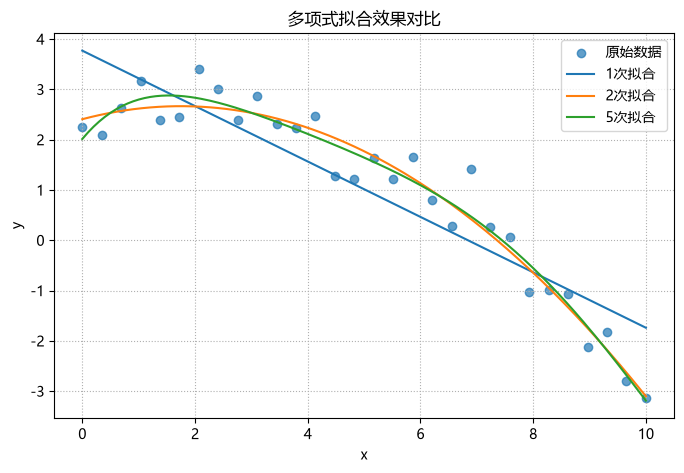

In [2]:
# 生成带噪声的示例数据：y = 2 + 0.5x - 0.1x^2 + 噪声。
x_data = np.linspace(0, 10, 30)
y_true = 2 + 0.5 * x_data - 0.1 * x_data**2
y_data = y_true + np.random.normal(0, 0.5, size=x_data.shape)

# 用 numpy.polyfit 拟合不同阶数的多项式。
# polyfit 的输入为 (x, y, deg)，deg 是多项式最高次数。
for deg in [1, 2, 5]:
    # polyfit 返回从高次到低次的系数数组。
    coeffs = np.polyfit(x_data, y_data, deg)
    # polyval 用系数数组计算多项式在给定 x 处的值。
    y_fit = np.polyval(coeffs, x_data)
    # R² 越接近 1 说明拟合越好，但阶数过高时 R² 会虚高。
    r2 = r2_score(y_data, y_fit)
    print(f"阶数={deg}, 系数={np.round(coeffs, 4)}, R²={r2:.4f}")

# 在密集体上计算拟合值，画出曲线对比。
plt.scatter(x_data, y_data, label='原始数据', alpha=0.7)
xs = np.linspace(0, 10, 200)
for deg in [1, 2, 5]:
    coeffs = np.polyfit(x_data, y_data, deg)
    plt.plot(xs, np.polyval(coeffs, xs), label=f'{deg}次拟合')
plt.xlabel('x'); plt.ylabel('y'); plt.title('多项式拟合效果对比')
plt.grid(ls=':'); plt.legend(); plt.show()


# 二、一元非线性拟合（curve_fit）

`curve_fit` 可以拟合任意用户自定义函数形式。它采用非线性最小二乘法迭代求解，对初值比较敏感，但非常灵活。

- **输入**：函数名、x 数据、y 数据、可选的初值 p0
- **输出**：最优参数、协方差矩阵（可计算标准误）
- **优点**：可以拟合任何数学表达式，比多项式更贴近物理/生物机理
- **缺点**：需要提供合理的初值；迭代可能不收敛；计算比多项式慢
- **适用场景**：已知或假设数据服从某种理论公式（指数衰减、Logistic 增长、Michaelis-Menten 等）


=== curve_fit 指数衰减拟合 ===
  真值:      a=5.0,    b=0.3,    c=1.0
  拟合值:    a=4.897, b=0.343, c=1.170
  标准误:    a=0.161, b=0.032, c=0.128
  R² = 0.9617


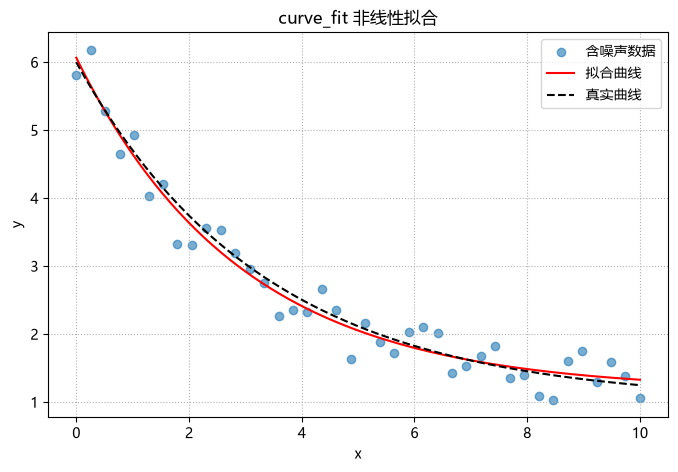

In [3]:
# 使用 curve_fit 拟合用户自定义的非线性函数。
# 先生成带噪声的指数衰减数据：y = 5 * exp(-0.3x) + 噪声。
def exponential_decay(x, a, b, c):
    # 指数衰减函数：a * exp(-b * x) + c，a 为初始值，b 为衰减率，c 为基线。
    return a * np.exp(-b * x) + c

x_exp = np.linspace(0, 10, 40)
y_exp_true = 5 * np.exp(-0.3 * x_exp) + 1
y_exp_data = y_exp_true + np.random.normal(0, 0.3, size=x_exp.shape)

# curve_fit 的输入格式为 (func, xdata, ydata, p0)。
# p0 是参数的初始猜测值，不提供则默认全为 1。
# 返回值为 (最优参数, 协方差矩阵)。
params, cov = curve_fit(exponential_decay, x_exp, y_exp_data, p0=[4, 0.5, 0])
# 协方差矩阵对角线的平方根即为参数的标准误。
perr = np.sqrt(np.diag(cov))

print("=== curve_fit 指数衰减拟合 ===")
print(f"  真值:      a=5.0,    b=0.3,    c=1.0")
print(f"  拟合值:    a={params[0]:.3f}, b={params[1]:.3f}, c={params[2]:.3f}")
print(f"  标准误:    a={perr[0]:.3f}, b={perr[1]:.3f}, c={perr[2]:.3f}")
y_fit_exp = exponential_decay(x_exp, *params)
print(f"  R² = {r2_score(y_exp_data, y_fit_exp):.4f}")

# 用拟合后的参数计算密集曲线，与原始数据一同绘制。
plt.scatter(x_exp, y_exp_data, label='含噪声数据', alpha=0.6)
xs_fine = np.linspace(0, 10, 200)
plt.plot(xs_fine, exponential_decay(xs_fine, *params), 'r-', label='拟合曲线')
plt.plot(xs_fine, exponential_decay(xs_fine, 5, 0.3, 1), 'k--', label='真实曲线')
plt.xlabel('x'); plt.ylabel('y'); plt.title('curve_fit 非线性拟合')
plt.grid(ls=':'); plt.legend(); plt.show()


# 三、多元线性回归（sklearn）

当自变量不止一个时，使用多元线性回归 $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \varepsilon$。

- **输入**：特征矩阵 X (n_samples, n_features)，目标向量 y (n_samples)
- **输出**：回归系数、截距、R²、预测值
- **优点**：可同时处理多个自变量；系数直接反映影响大小和方向
- **缺点**：假设线性关系；对异常值敏感；特征间的多重共线性会使系数不稳定
- **适用场景**：探索多个因素对一个结果的影响；作为更复杂模型的基准


=== 多元线性回归 ===
  真值:      截距=3.0, X1=2.0, X2=-1.5
  拟合系数:  截距=3.044, X1=2.113, X2=-1.506
  R² = 0.9582
  RMSE = 0.5295

  回归方程: y = 3.044 + (2.113)*X1 + (-1.506)*X2


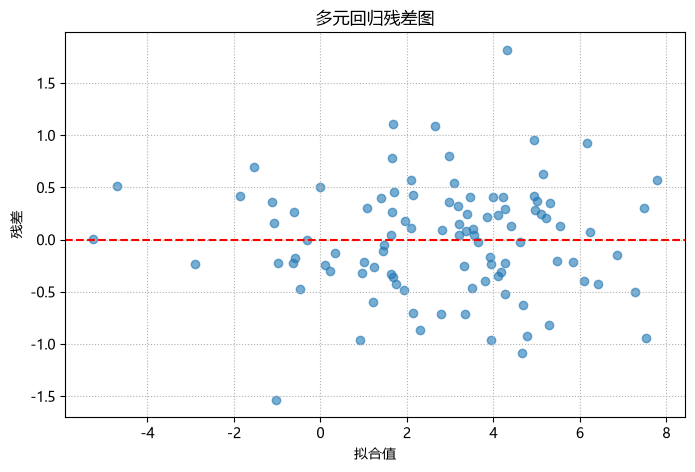

In [4]:
# 使用 sklearn 的 LinearRegression 进行多元线性回归。
# 构造两个自变量 X1、X2，目标 y = 3 + 2*X1 - 1.5*X2 + 噪声。
np.random.seed(42)
n = 100
X1 = np.random.randn(n)
X2 = np.random.randn(n)
y_multi = 3 + 2 * X1 - 1.5 * X2 + np.random.normal(0, 0.5, n)

# 将两个自变量合并为特征矩阵，每行一个样本，每列一个特征。
X_multi = np.column_stack([X1, X2])

# LinearRegression 自动拟合截距项(fit_intercept=True)。
lr = LinearRegression()
lr.fit(X_multi, y_multi)

# 截距保存在 intercept_，各特征的系数保存在 coef_ 中。
y_pred_multi = lr.predict(X_multi)
print("=== 多元线性回归 ===")
print(f"  真值:      截距=3.0, X1=2.0, X2=-1.5")
print(f"  拟合系数:  截距={lr.intercept_:.3f}, X1={lr.coef_[0]:.3f}, X2={lr.coef_[1]:.3f}")
print(f"  R² = {r2_score(y_multi, y_pred_multi):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_multi, y_pred_multi)):.4f}")

# 打印回归方程供论文使用。
print(f"\n  回归方程: y = {lr.intercept_:.3f}", end='')
for i, c in enumerate(lr.coef_):
    print(f" + ({c:.3f})*X{i+1}", end='')
print()

# 残差图：残差应该随机分布在 0 附近，无明显模式。
residuals = y_multi - y_pred_multi
plt.scatter(y_pred_multi, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('拟合值'); plt.ylabel('残差')
plt.title('多元回归残差图'); plt.grid(ls=':'); plt.show()


# 四、岭回归（Ridge Regression, L2 正则化）

岭回归在损失函数中加入系数的 L2 范数惩罚 $\lambda \sum \beta_j^2$，使参数压缩但不为零，适合处理特征间存在多重共线性的情况。

- **输入**：特征矩阵 X，目标 y，正则化强度 alpha
- **输出**：回归系数（比普通最小二乘更小更稳定）
- **优点**：改善多重共线性；系数估计更稳健；alpha 越大压缩越强
- **缺点**：所有特征都被保留（不筛选特征）；需要交叉验证选择 alpha
- **适用场景**：特征维度高、特征间存在相关、普通最小二乘的系数方差过大


In [5]:
# 在具有共线性的数据上对比普通线性回归与岭回归的效果。
# 构造两个高度相关的自变量（相关性 > 0.9）。
np.random.seed(42)
n = 100
X1 = np.random.randn(n)
X2 = 0.95 * X1 + 0.1 * np.random.randn(n)  # X2 几乎等于 X1
y_collinear = 3 + 2 * X1 - 1.5 * X2 + np.random.normal(0, 0.3, n)
X_collinear = np.column_stack([X1, X2])

# 普通最小二乘回归。
lr_plain = LinearRegression()
lr_plain.fit(X_collinear, y_collinear)

# 岭回归：添加 L2 正则化，alpha 控制惩罚强度。
# alpha 越大，系数越向 0 压缩；alpha=0 退化为普通最小二乘。
for alpha in [0.1, 1, 10]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_collinear, y_collinear)
    y_ridge_pred = ridge.predict(X_collinear)
    print(f"  Ridge(alpha={alpha:4.1f}): 截距={ridge.intercept_:.3f}, "
          f"X1={ridge.coef_[0]:.3f}, X2={ridge.coef_[1]:.3f}, R²={r2_score(y_collinear, y_ridge_pred):.4f}")

print(f"\n  OLS(无正则化):        截距={lr_plain.intercept_:.3f}, X1={lr_plain.coef_[0]:.3f}, X2={lr_plain.coef_[1]:.3f}")
print(f"  真值:                 截距=3.0,    X1=2.0,    X2=-1.5")
print("\n  共线性越强，OLS 的系数波动越大；岭回归通过压缩系数使其更稳定。")


  Ridge(alpha= 0.1): 截距=3.026, X1=1.795, X2=-1.210, R²=0.7890
  Ridge(alpha= 1.0): 截距=3.025, X1=0.907, X2=-0.270, R²=0.7614
  Ridge(alpha=10.0): 截距=3.020, X1=0.406, X2=0.224, R²=0.7300

  OLS(无正则化):        截距=3.027, X1=2.103, X2=-1.537
  真值:                 截距=3.0,    X1=2.0,    X2=-1.5

  共线性越强，OLS 的系数波动越大；岭回归通过压缩系数使其更稳定。


# 五、Lasso 回归（L1 正则化，特征选择）

Lasso 使用 L1 范数惩罚 $\lambda \sum |\beta_j|$，不仅压缩系数，还会把不重要的特征系数变为 0，实现自动特征选择。

- **输入**：特征矩阵 X，目标 y，正则化强度 alpha
- **输出**：稀疏的回归系数（部分为 0）
- **优点**：自动筛选重要特征；模型更简洁、可解释性强
- **缺点**：相关特征组中只随机选一个；alpha 选择需调参
- **适用场景**：特征数量远多于样本数；或想从大量变量中找出关键少数


In [6]:
# 构造含多个无关特征的数据，展示 Lasso 的自动特征选择能力。
# 只有前 3 个特征对 y 有贡献，其余 17 个是无关噪声。
np.random.seed(42)
n, p = 80, 20
X_lasso = np.random.randn(n, p)
beta_true = np.array([3, -2, 1.5] + [0] * (p - 3))
y_lasso = X_lasso @ beta_true + np.random.normal(0, 0.5, n)

# Lasso 的 alpha 越大，系数越稀疏（更多为 0）。
for alpha in [0.01, 0.1, 1]:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_lasso, y_lasso)
    n_selected = np.sum(np.abs(lasso.coef_) > 1e-6)
    y_lasso_pred = lasso.predict(X_lasso)
    print(f"  Lasso(alpha={alpha:.2f}): R²={r2_score(y_lasso, y_lasso_pred):.3f}, "
          f"选中特征数={n_selected}/{p}")

# 用较小的 alpha 展示 Lasso 的系数路径（哪些特征被保留）。
lasso_final = Lasso(alpha=0.05, max_iter=10000)
lasso_final.fit(X_lasso, y_lasso)
print(f"\n  Lasso(alpha=0.05) 选中的特征索引:")
selected_idx = np.where(np.abs(lasso_final.coef_) > 1e-6)[0]
print(f"  {selected_idx}")
print(f"  对应系数: {lasso_final.coef_[selected_idx]}")
print(f"\n  只有对 y 真有贡献的特征被保留，无关特征系数为 0。")


  Lasso(alpha=0.01): R²=0.988, 选中特征数=16/20
  Lasso(alpha=0.10): R²=0.986, 选中特征数=3/20
  Lasso(alpha=1.00): R²=0.862, 选中特征数=3/20

  Lasso(alpha=0.05) 选中的特征索引:
  [ 0  1  2  3  4 13 19]
  对应系数: [ 2.91357962e+00 -1.92335285e+00  1.51296461e+00  3.48924041e-02
 -1.68912309e-03 -2.06159574e-02  1.74675125e-03]

  只有对 y 真有贡献的特征被保留，无关特征系数为 0。


# 六、稳健拟合（least_squares，抵抗异常值）

普通最小二乘法对异常值非常敏感——一个离群点就足以把拟合曲线拉偏。`scipy.optimize.least_squares` 可以通过选择损失函数（如 `'soft_l1'`、`'huber'`）自动降低大残差样本的权重。

- **输入**：残差函数（计算拟合值与真实值的差）、初值、损失函数类型
- **输出**：最优参数、残差详情
- **优点**：自动降低异常值影响；无需手动剔除数据
- **缺点**：计算量比普通最小二乘大；需要合理初值
- **适用场景**：数据中存在明显异常值（如测量错误、录入错误）；希望算法自动处理


=== 稳健拟合对比 ===
  真值:                     y = 2.000x + 1.000
  普通最小二乘(OLS):        y = 2.042x + 2.242
  稳健拟合(soft_l1):        y = 2.009x + 1.561

  异常值位置索引: [5, 15, 25]


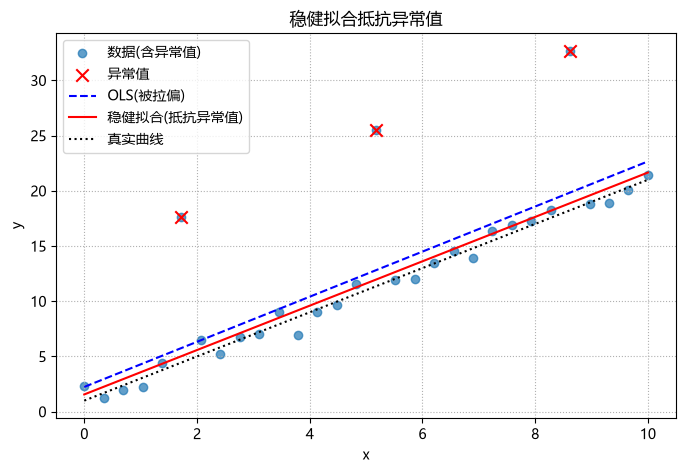

In [7]:
# 在含异常值的数据上对比普通最小二乘与稳健拟合的效果。
# 生成线性数据 y = 2x + 1，然后手动加入 3 个异常点。
np.random.seed(1)
x_rob = np.linspace(0, 10, 30)
y_rob = 2 * x_rob + 1 + np.random.normal(0, 0.8, size=x_rob.shape)
# 加入 3 个明显偏离的异常值。
outlier_idx = [5, 15, 25]
y_rob[outlier_idx] += 15

# 普通最小二乘拟合（用 numpy.polyfit）。
coeffs_ols = np.polyfit(x_rob, y_rob, 1)

# 稳健拟合：使用 least_squares，损失函数用 'soft_l1' 以抵抗异常值。
# least_squares 需要残差函数（返回残差向量），而不是残差平方和。
def residuals(params, x, y):
    a, b = params
    return y - (a * x + b)

# 损失函数可选: 'linear'(普通最小二乘), 'soft_l1', 'huber', 'cauchy', 'arctan'。
# soft_l1 和 huber 在残差大时自动降低权重，从而抵抗异常值。
result_robust = least_squares(
    residuals, [1, 0],  # 初值猜测
    args=(x_rob, y_rob),
    loss='soft_l1',      # 稳健损失函数
    f_scale=5.0          # 控制"多大残差算异常"，越小越严格
)
a_rob, b_rob = result_robust.x

print("=== 稳健拟合对比 ===")
print(f"  真值:                     y = 2.000x + 1.000")
print(f"  普通最小二乘(OLS):        y = {coeffs_ols[0]:.3f}x + {coeffs_ols[1]:.3f}")
print(f"  稳健拟合(soft_l1):        y = {a_rob:.3f}x + {b_rob:.3f}")
print(f"\n  异常值位置索引: {outlier_idx}")

# 绘制对比图，直观展示两种方法的差异。
plt.scatter(x_rob, y_rob, label='数据(含异常值)', alpha=0.7)
plt.scatter(x_rob[outlier_idx], y_rob[outlier_idx], color='red', s=80,
            marker='x', label='异常值', zorder=5)
xs = np.linspace(0, 10, 200)
plt.plot(xs, np.polyval(coeffs_ols, xs), 'b--', label='OLS(被拉偏)')
plt.plot(xs, a_rob * xs + b_rob, 'r-', label='稳健拟合(抵抗异常值)')
plt.plot(xs, 2 * xs + 1, 'k:', label='真实曲线')
plt.xlabel('x'); plt.ylabel('y'); plt.title('稳健拟合抵抗异常值')
plt.grid(ls=':'); plt.legend(); plt.show()


# 七、分段线性拟合（Piecewise Linear Fitting）

当数据在不同区间呈不同斜率时，用一个整体公式无法描述。分段线性拟合找出"转折点"（断点），每段分别拟合直线。

- **输入**：x、y 数据，以及断点数量或位置
- **输出**：每段的斜率和截距，以及断点位置
- **优点**：比单一线性或高阶多项式更贴近实际；物理意义明确
- **缺点**：断点位置需要手动指定或通过优化求解；参数较多
- **适用场景**：生长曲线存在转折、成本随产量阶梯变化、实验中不同阶段的不同趋势


=== 分段线性拟合 ===
  真值:    a1=0.5, a2=-0.3, c=5.0
  估计值:  a1=0.465, a2=-0.275, c=5.103
  R² = 0.8367


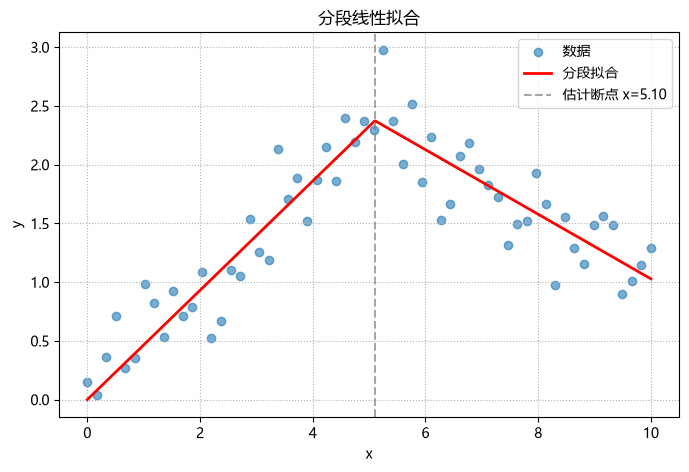

In [8]:
# 实现分段线性拟合：通过 curve_fit 同时优化断点和两段斜率。
# 分段函数形式：斜率在断点处从 a1 变为 a2，但保证连续。
# y = a1 * x + b1,  x <= c
# y = a2 * x + b2,  x > c
# 连续性条件 a1*c + b1 = a2*c + b2 保证了曲线不断开。

def piecewise_linear(x, a1, a2, c):
    # x <= c 时使用第一段斜率 a1，x > c 时使用第二段斜率 a2。
    # 连续性条件：b1 = c*(a2-a1) + b1_est，其中 b1_est 是为拟合自由参数。
    # 为减少参数数量，固定左侧截距为 b1，用连续性推出右侧截距。
    b1 = 0  # 固定左侧截距为 0，模型自由度 = 3
    b2 = (a1 - a2) * c + b1  # 由连续性条件推出
    return np.piecewise(x, [x <= c, x > c],
                        [lambda x: a1 * x + b1, lambda x: a2 * x + b2])

# 生成在 x=5 处斜率从 0.5 变为 -0.3 的数据。
np.random.seed(42)
x_pw = np.linspace(0, 10, 60)
y_pw = piecewise_linear(x_pw, 0.5, -0.3, 5) + np.random.normal(0, 0.3, size=x_pw.shape)

# 使用 curve_fit 估计 a1, a2, c 三个参数，需提供合理初值。
params_pw, _ = curve_fit(piecewise_linear, x_pw, y_pw, p0=[0.4, -0.2, 4.5])
a1_est, a2_est, c_est = params_pw

print("=== 分段线性拟合 ===")
print(f"  真值:    a1=0.5, a2=-0.3, c=5.0")
print(f"  估计值:  a1={a1_est:.3f}, a2={a2_est:.3f}, c={c_est:.3f}")
y_pw_pred = piecewise_linear(x_pw, a1_est, a2_est, c_est)
print(f"  R² = {r2_score(y_pw, y_pw_pred):.4f}")

# 画出拟合结果与原始数据。
plt.scatter(x_pw, y_pw, alpha=0.6, label='数据')
xs = np.linspace(0, 10, 500)
plt.plot(xs, piecewise_linear(xs, a1_est, a2_est, c_est), 'r-', linewidth=2, label='分段拟合')
plt.axvline(c_est, color='gray', linestyle='--', alpha=0.7, label=f'估计断点 x={c_est:.2f}')
plt.xlabel('x'); plt.ylabel('y'); plt.title('分段线性拟合')
plt.grid(ls=':'); plt.legend(); plt.show()


# 八、多项式回归管道（PolynomialFeatures + Pipeline）

`sklearn` 的 `Pipeline` 可将特征构造和线性回归串联，一次完成"先构造多项式特征再进行拟合"的全流程，方便交叉验证和调参。

- **输入**：原始单变量 x，目标 y
- **输出**：自动构造多项式特征后的回归模型
- **优点**：代码简洁；可与 GridSearchCV 配合调参；统一接口
- **缺点**：与 numpy.polyfit 本质相同，注意不要用过高的 degree
- **适用场景**：想在 sklearn 生态下使用多项式拟合；需要与其他预处理步骤串联


  Pipeline(degree=1): 截距=3.770, 系数=[-0.551], R²=0.8154
  Pipeline(degree=2): 截距=2.406, 系数=[ 0.2963 -0.0847], R²=0.9524
  Pipeline(degree=3): 截距=2.363, 系数=[ 0.3532 -0.0992  0.001 ], R²=0.9525


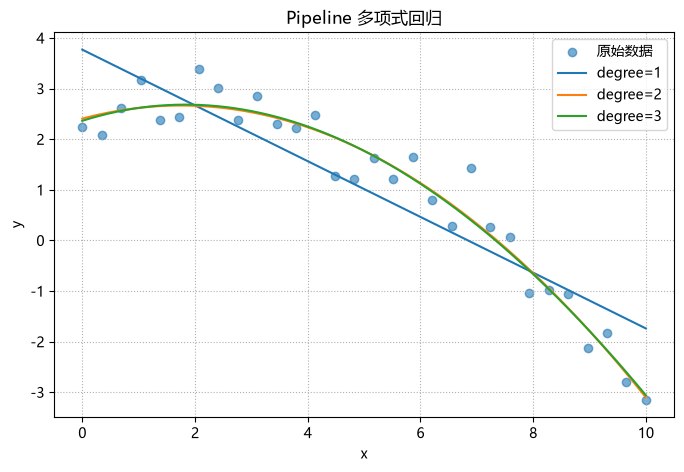

In [9]:
# 使用 sklearn 的 Pipeline 串联多项式特征构造与线性回归。
# 仍用第一节的示例数据。
x_pipe = x_data.reshape(-1, 1)  # sklearn 要求特征为二维

# make_pipeline 将多个变换步骤和最终估计器串联。
# PolynomialFeatures(degree, include_bias=False) 构造 x, x^2, x^3, ... 等特征。
# include_bias=False 表示不自动加常数项（LinearRegression 自己会加截距）。
for degree in [1, 2, 3]:
    pipe = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    pipe.fit(x_pipe, y_data)
    y_pipe_pred = pipe.predict(x_pipe)
    # 取出管道中 LinearRegression 的系数。
    coef = pipe.named_steps['linearregression'].coef_
    intercept = pipe.named_steps['linearregression'].intercept_
    print(f"  Pipeline(degree={degree}): 截距={intercept:.3f}, 系数={np.round(coef, 4)}, "
          f"R²={r2_score(y_data, y_pipe_pred):.4f}")

# 在密集点上计算拟合曲线。
xs = np.linspace(0, 10, 200).reshape(-1, 1)
plt.scatter(x_data, y_data, alpha=0.6, label='原始数据')
for degree in [1, 2, 3]:
    pipe = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    pipe.fit(x_pipe, y_data)
    plt.plot(xs, pipe.predict(xs), label=f'degree={degree}')
plt.xlabel('x'); plt.ylabel('y'); plt.title('Pipeline 多项式回归')
plt.grid(ls=':'); plt.legend(); plt.show()


# 九、拟合优度指标与质量评估

拟合完成后需要从多个角度判断拟合质量。下面汇总最常用的指标，并用同一组数据演示它们的计算和解读。

$$R^2 = 1 - \frac{SSE}{SST},\quad
RMSE = \sqrt{\frac{1}{n}\sum (y_i-\hat{y}_i)^2},\quad
MAE = \frac{1}{n}\sum |y_i-\hat{y}_i|$$

$$AIC = 2k - 2\ln(\hat{L}),\quad
BIC = k\ln(n) - 2\ln(\hat{L})$$

| 指标 | 含义 | 理想值 | 说明 |
|------|------|--------|------|
| R² | 模型解释的方差比例 | 越接近 1 越好 | 随自变量增加虚高 |
| 调整 R² | 惩罚自变量个数的 R² | 越接近 1 越好 | 用于比较不同变量数的模型 |
| RMSE | 预测误差的均方根 | 越小越好 | 与 y 量纲一致 |
| MAE | 预测误差的绝对值均值 | 越小越好 | 比 RMSE 更抗异常值 |
| AIC / BIC | 信息准则（拟合好 + 参数少） | 越小越好 | 用于模型选择 |


=== 不同阶数拟合的优度指标对比 ===
   阶数      R²    调整R²    RMSE     MAE      AIC      BIC
0   1  0.8154  0.8088  0.7824  0.6418 -10.7266  -7.9242
1   2  0.9524  0.9489  0.3973  0.3241 -49.3795 -45.1759
2   3  0.9525  0.9470  0.3968  0.3249 -47.4557 -41.8509
3   6  0.9592  0.9486  0.3676  0.3012 -46.0427 -36.2344


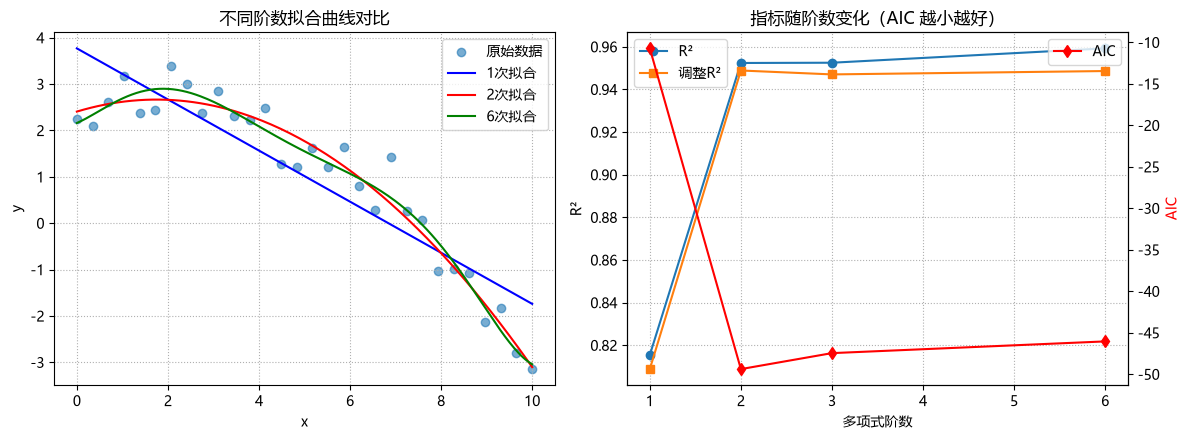


建议：AIC 最小的阶数为 2 次，此时调整 R² = 0.9489


In [11]:
# 沿用第一节的二次多项式数据，对比不同阶数拟合的各类指标。
# 先计算各阶数对应的残差、似然等信息。
results = []
for deg in [1, 2, 3, 6]:
    coeffs = np.polyfit(x_data, y_data, deg)
    y_fit = np.polyval(coeffs, x_data)
    n = len(y_data)
    k = deg + 1  # 参数个数（含截距）
    residuals = y_data - y_fit
    sse = np.sum(residuals ** 2)
    sst = np.sum((y_data - np.mean(y_data)) ** 2)
    
    # R²：模型解释的方差比例，过高可能过拟合。
    r2 = 1 - sse / sst
    # 调整 R²：对自变量个数做惩罚，防止阶数虚高。
    adj_r2 = 1 - (sse / (n - k)) / (sst / (n - 1))
    # RMSE：均方根误差，与 y 量纲一致。
    rmse = np.sqrt(sse / n)
    # MAE：平均绝对误差，比 RMSE 更抗异常值。
    mae = np.mean(np.abs(residuals))
    # AIC 和 BIC：信息准则，值越小模型越优（拟合好 + 参数少）。
    # 对 OLS，AIC = n*ln(SSE/n) + 2k，BIC = n*ln(SSE/n) + k*ln(n)。
    aic = n * np.log(sse / n) + 2 * k
    bic = n * np.log(sse / n) + k * np.log(n)
    
    results.append([deg, r2, adj_r2, rmse, mae, aic, bic])

tab = pd.DataFrame(results, columns=['阶数', 'R²', '调整R²', 'RMSE', 'MAE', 'AIC', 'BIC'])
print("=== 不同阶数拟合的优度指标对比 ===")
print(tab.round(4))

# 随阶数增加，R² 持续上升（趋于 1），但调整 R² 和 AIC/BIC 会拐弯。
# 调整 R² 最大、AIC/BIC 最小的阶数通常是"性价比"最好的。

# 用两个子图直观展示拟合效果与指标的关系。
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 左图：数据和拟合曲线。
ax1.scatter(x_data, y_data, alpha=0.6, label='原始数据')
xs = np.linspace(0, 10, 200)
for deg, color in zip([1, 2, 6], ['blue', 'red', 'green']):
    coeffs = np.polyfit(x_data, y_data, deg)
    ax1.plot(xs, np.polyval(coeffs, xs), color=color, label=f'{deg}次拟合')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('不同阶数拟合曲线对比')
ax1.grid(ls=':'); ax1.legend()

# 右图：R²、调整 R²、AIC 随阶数的变化。
deg_list = tab['阶数'].values
ax2.plot(deg_list, tab['R²'], 'o-', label='R²')
ax2.plot(deg_list, tab['调整R²'], 's-', label='调整R²')
ax2_twin = ax2.twinx()
ax2_twin.plot(deg_list, tab['AIC'], 'd-', color='red', label='AIC')
ax2.set_xlabel('多项式阶数'); ax2.set_ylabel('R²')
ax2_twin.set_ylabel('AIC', color='red')
ax2.set_title('指标随阶数变化（AIC 越小越好）')
ax2.grid(ls=':'); ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
plt.tight_layout(); plt.show()

# 实操建议：选调整 R² 最高或 AIC 最低的阶数，而不是单纯看 R²。
best_deg = tab.loc[tab['AIC'].idxmin(), '阶数']
print(f"\n建议：AIC 最小的阶数为 {int(best_deg)} 次，此时调整 R² = {tab.loc[tab['AIC'].idxmin(), '调整R²']:.4f}")

# 十、参数敏感性分析

敏感性分析研究模型输出对参数变动的敏感程度。如果一个参数稍微改变就让结果大幅波动，说明模型对该参数敏感，使用时要格外小心。

常用方法有两类：

| 方法 | 做法 | 适用场景 |
|------|------|---------|
| 单参数扰动（OAT） | 每次只变一个参数，其余固定 | 初步筛查哪些参数重要 |
| 全局敏感性（Sobol） | 所有参数同时随机变化 | 参数间存在交互作用时 |

下面用 Logistic 增长模型分别演示单参数扰动和参数相关性热图。


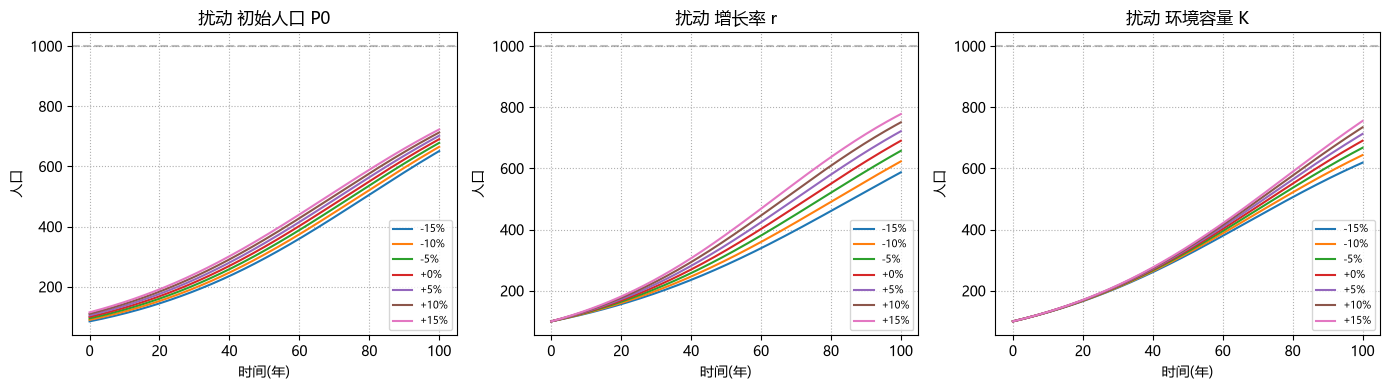

=== 单参数扰动分析（终点人口 P(100) 的变动幅度）===
        参数  最敏感扰动  终点人口极差
0  初始人口 P0  -0.15   71.92
1    增长率 r  -0.15  190.49
2   环境容量 K  -0.15  136.30


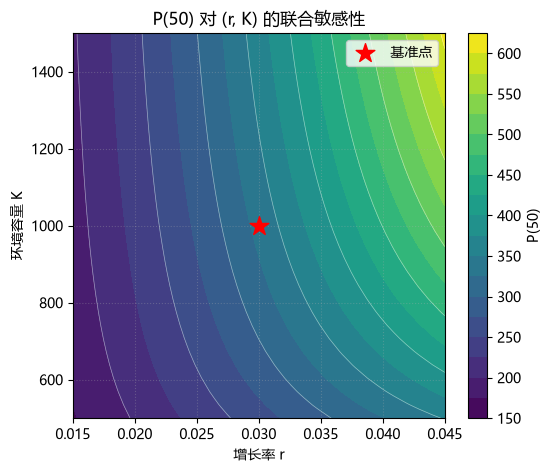


=== 参数相关性热图分析 ===
红色星号 = 基准参数点
等高线越密集，P(50) 对该区域的参数越敏感。
等高线走向越平缓，两个参数的交互作用越强。


In [12]:
# 用 Logistic 增长模型 P(t) = K / (1 + (K/P0 - 1)*exp(-r*t)) 做敏感性分析。
# 先定义 Logistic 的解析解函数。
def logistic_solution(t, P0, r, K):
    return K / (1 + (K / P0 - 1) * np.exp(-r * t))

# 设定基准参数。
P0_base, r_base, K_base = 100, 0.03, 1000
t_year = np.linspace(0, 100, 200)
y_base = logistic_solution(t_year, P0_base, r_base, K_base)

# ---- 方法 A: 单参数扰动（OAT）----
# 每次只扰动一个参数，观察终点人口 P(100) 的变化。
# 扰动幅度设为 ±5%、±10%、±15%。
perturbations = np.array([-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15])
results_oat = []

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
params = [
    ('初始人口 P0', P0_base, 0),
    ('增长率 r', r_base, 1),
    ('环境容量 K', K_base, 2)
]

for param_name, base_val, idx in params:
    y_end_list = []
    for delta in perturbations:
        val = base_val * (1 + delta)
        if param_name == '初始人口 P0':
            y = logistic_solution(t_year, val, r_base, K_base)
        elif param_name == '增长率 r':
            y = logistic_solution(t_year, P0_base, val, K_base)
        else:
            y = logistic_solution(t_year, P0_base, r_base, val)
        axes[idx].plot(t_year, y, label=f'{delta*100:+.0f}%')
        y_end_list.append(y[-1])
    axes[idx].axhline(K_base, color='gray', ls='--', alpha=0.5)
    axes[idx].set_xlabel('时间(年)'); axes[idx].set_ylabel('人口')
    axes[idx].set_title(f'扰动 {param_name}')
    axes[idx].grid(ls=':'); axes[idx].legend(fontsize=7)
    results_oat.append([param_name, perturbations[np.argmax(np.abs(np.array(y_end_list) - y_base[-1]))],
                        max(y_end_list) - min(y_end_list)])

plt.tight_layout(); plt.show()

# 输出各参数的终点人口变动范围，直观反映敏感程度。
print("=== 单参数扰动分析（终点人口 P(100) 的变动幅度）===")
oat_table = pd.DataFrame(results_oat, columns=['参数', '最敏感扰动', '终点人口极差'])
print(oat_table.round(2))

# ---- 方法 B: 参数相关性热图（双参数同时扰动）----
# 同时扰动 r 和 K，看两者如何共同影响第 50 年的人口 P(50)。
r_grid = np.linspace(r_base * 0.5, r_base * 1.5, 30)
K_grid = np.linspace(K_base * 0.5, K_base * 1.5, 30)
RM, KM = np.meshgrid(r_grid, K_grid)
# 计算 P(50) 作为输出指标。
P50 = logistic_solution(50, P0_base, RM, KM)

fig2, ax2 = plt.subplots(figsize=(6, 5))
contour = ax2.contourf(RM, KM, P50, levels=20, cmap='viridis')
ax2.contour(RM, KM, P50, levels=8, colors='white', linewidths=0.5, alpha=0.5)
ax2.scatter([r_base], [K_base], color='red', marker='*', s=200, label='基准点', zorder=5)
ax2.set_xlabel('增长率 r'); ax2.set_ylabel('环境容量 K')
ax2.set_title('P(50) 对 (r, K) 的联合敏感性')
plt.colorbar(contour, ax=ax2, label='P(50)')
ax2.legend(); ax2.grid(ls=':', alpha=0.3); plt.show()

# 在等高线密集的区域，P(50) 对参数变化最敏感。
print("\n=== 参数相关性热图分析 ===")
print("红色星号 = 基准参数点")
print("等高线越密集，P(50) 对该区域的参数越敏感。")
print("等高线走向越平缓，两个参数的交互作用越强。")

# 方法对比速查表

| 方法 | 函数/类 | 核心参数 | 抗异常值 | 特征选择 | 主要优势 |
|------|---------|---------|---------|---------|---------|
| 多项式拟合 | `np.polyfit(x, y, deg)` | deg（阶数） | 否 | 否 | 最简单快速 |
| 非线性拟合 | `curve_fit(func, x, y, p0)` | func（自定义函数） | 否 | 否 | 任意函数形式 |
| 多元线性回归 | `LinearRegression().fit(X, y)` | 无 | 否 | 否 | 多自变量，系数可解释 |
| 岭回归 | `Ridge(alpha)` | alpha（正则强度） | 否 | 否（压缩但不为 0） | 改善共线性 |
| Lasso | `Lasso(alpha)` | alpha（正则强度） | 否 | 是（系数为 0） | 自动特征筛选 |
| 稳健拟合 | `least_squares(..., loss='soft_l1')` | loss（损失函数） | **是** | 否 | 抵抗异常值 |
| 分段线性拟合 | `curve_fit` 自定义分段函数 | 断点位置 c | 否 | 否 | 不同区间不同斜率 |
| Pipeline 多项式 | `make_pipeline(PolynomialFeatures, LinearRegression)` | degree（阶数） | 否 | 否 | sklearn 生态集成 |


In [10]:
# 验证报告函数：将拟合结果整理为统一格式，便于检查或导出。
def fitting_report(problem, method, params, r2, rmse, extra=None):
    items = {
        '问题': problem,
        '方法': method,
        '参数': np.round(params, 4),
        'R²': round(r2, 4),
        'RMSE': round(rmse, 4)
    }
    if extra:
        items.update(extra)
    return pd.DataFrame({'项目': items.keys(), '内容': items.values()})

# 以指数衰减拟合为例生成验证报告。
report = fitting_report(
    '指数衰减 y = a*exp(-b*x) + c',
    'curve_fit',
    params,
    r2_score(y_exp_data, y_fit_exp),
    np.sqrt(mean_squared_error(y_exp_data, y_fit_exp)),
    {'标准误': np.round(perr, 4), '迭代收敛': result_robust.success if 'result_robust' in dir() else True}
)
report


,项目,内容
0,问题,指数衰减 y = a*exp(-b*x) + c
1,方法,curve_fit
2,参数,"[4.8969, 0.3426, 1.1698]"
3,R²,0.9617
4,RMSE,0.2617
5,标准误,"[0.1606, 0.0317, 0.1281]"
6,迭代收敛,True


# 使用建议

1. **先画散点图** — 观察数据分布是直线、曲线、还是有断点，再选方法
2. **从简单开始** — 多项式拟合或线性回归先做基线，再尝试复杂模型
3. **检查残差** — 拟合后看残差是否随机分布在 0 附近，如有明显模式说明模型形式不对
4. **R² 不是唯一的** — 阶数太高 R² 会虚高，结合 RMSE 和模型复杂度一起判断
5. **异常值先处理** — 有离群点时用稳健拟合，或先清洗数据
6. **参数初值要合理** — curve_fit 和 least_squares 需要接近真值的初值才能收敛
7. **验证泛化能力** — 用交叉验证或留出测试集评估，避免过拟合

课后可以试着修改各段代码的参数（多项式阶数、alpha 强度、损失函数类型），观察结果如何变化。


# 十一、数据平滑方法

平滑用于降低数据中的随机噪声、突出整体趋势，是拟合前常用的预处理手段。

| 方法 | 核心思想 | 适用场景 |
|------|---------|---------|
| 移动平均 (SMA) | 窗口内等权平均 | 快速看趋势，噪声均匀 |
| 指数平滑 (EMA) | 越近权重大，$\hat{y}_t=\alpha y_t+(1-\alpha)\hat{y}_{t-1}$ | 在线实时平滑，趋势跟随 |
| 样条平滑 | 平衡拟合优度与二阶导数惩罚 $\min\sum(y_i-f(x_i))^2+\lambda\int f''^2 dx$ | 需要光滑解析曲线 |
| Savitzky-Golay | 局部多项式最小二乘 | 保留峰形与宽度，信号特征损失小 |

下面用同一组含噪声的数据演示四种方法。


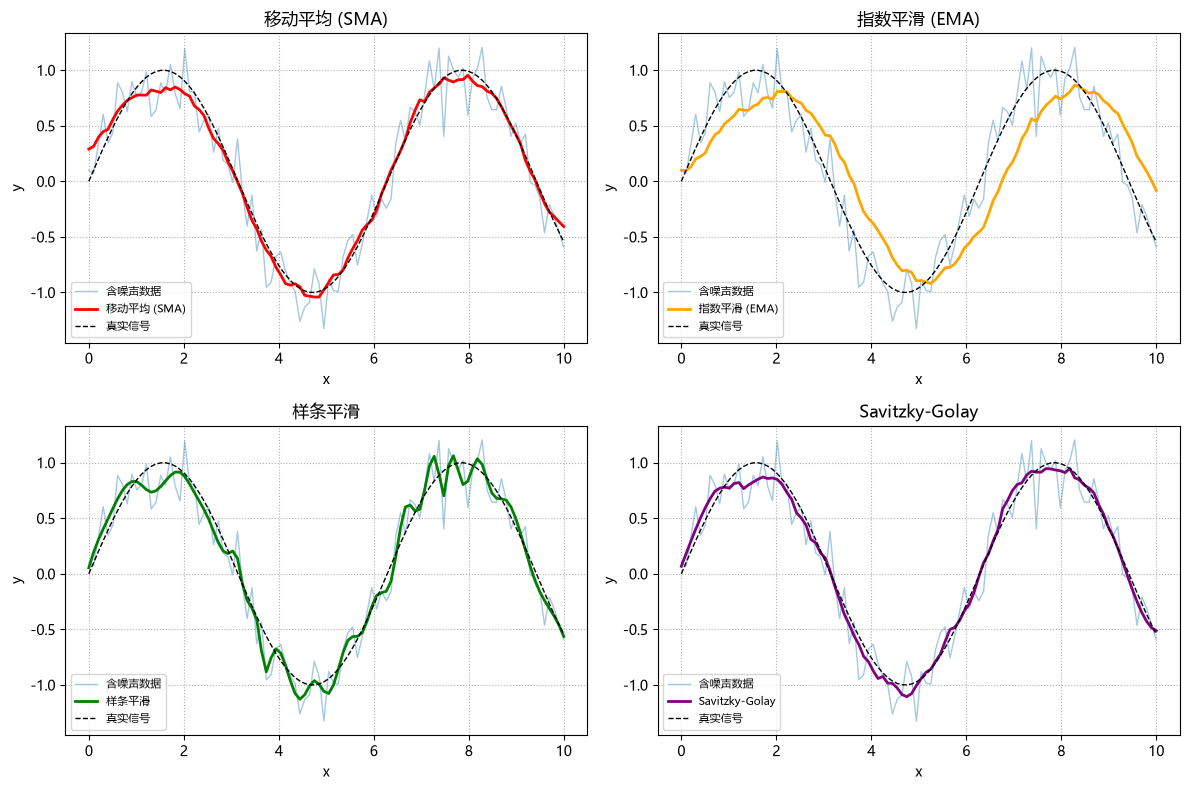

=== 四种平滑方法对真实信号的还原误差 (RMSE) ===
  移动平均 (SMA)         RMSE = 0.0813
  指数平滑 (EMA)         RMSE = 0.3038
  样条平滑               RMSE = 0.1075
  Savitzky-Golay     RMSE = 0.0725

  RMSE 越小，说明平滑结果越接近真实信号（在此示例中噪声为正态白噪声）。


In [4]:
# 生成带噪声的信号：y = sin(x) + 噪声。
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline

np.random.seed(42)
x_smooth = np.linspace(0, 10, 100)
y_true_smooth = np.sin(x_smooth)
y_noisy = y_true_smooth + np.random.normal(0, 0.2, size=x_smooth.shape)

# ---- 方法 1: 简单移动平均 (SMA) ----
# 窗口大小 window 控制平滑程度，越大越平滑但滞后越明显。
# min_periods=1 保证窗口边缘也能取到均值（不产生 NaN）。
window = 9
y_sma = pd.Series(y_noisy).rolling(window=window, center=True, min_periods=1).mean().values

# ---- 方法 2: 指数平滑 (EMA) ----
# alpha 越大越跟随原始数据（平滑弱），越小越平滑（滞后强）。
# 适用于在线流式数据，只需保存上一个状态。
alpha = 0.15
y_ema = pd.Series(y_noisy).ewm(alpha=alpha, adjust=False).mean().values

# ---- 方法 3: 样条平滑 ----
# s 为平滑参数，越大曲线越光滑；k 为样条阶数(常用 3)。
# 适用于需要得到可求值的解析函数表达式。
spline = UnivariateSpline(x_smooth, y_noisy, k=3, s=2.0)
y_spline = spline(x_smooth)

# ---- 方法 4: Savitzky-Golay 滤波 ----
# window_length 为窗口长度(必须为奇数)，polyorder 为局部多项式阶数。
# 优于移动平均的地方是能保留峰形和宽度。
y_sg = savgol_filter(y_noisy, window_length=15, polyorder=3)

# 绘制四种平滑结果与原始数据对比。
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
methods = [
    ('移动平均 (SMA)', y_sma, 'red'),
    ('指数平滑 (EMA)', y_ema, 'orange'),
    ('样条平滑', y_spline, 'green'),
    ('Savitzky-Golay', y_sg, 'purple')
]
for ax, (name, y_smoothed, color) in zip(axes.ravel(), methods):
    ax.plot(x_smooth, y_noisy, alpha=0.4, lw=1, label='含噪声数据')
    ax.plot(x_smooth, y_smoothed, color=color, lw=2, label=name)
    ax.plot(x_smooth, y_true_smooth, 'k--', lw=1, label='真实信号')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(name); ax.grid(ls=':'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 用 RMSE 定量比较四种方法对真实信号的还原程度。
print("=== 四种平滑方法对真实信号的还原误差 (RMSE) ===")
smooth_results = []
for name, y_smoothed, _ in methods:
    rmse_s = np.sqrt(np.mean((y_smoothed - y_true_smooth) ** 2))
    smooth_results.append([name, rmse_s])
    print(f"  {name:<18} RMSE = {rmse_s:.4f}")

smooth_table = pd.DataFrame(smooth_results, columns=['方法', 'RMSE'])
print(f"\n  RMSE 越小，说明平滑结果越接近真实信号（在此示例中噪声为正态白噪声）。")